Architecture Two:
* Uses only two convolutional layer
* Tested using different loss functions (weighted & unweighted, hinge)


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

import os
from PIL import Image

from myDataset import *

# imports loss, accuracy and confusion matrix plots
from MetricMethods import *

# imports train, test methods
from ArchitectureMethods import *



seed = 42
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.cpu.manual_seed = seed
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

torch.cuda.empty_cache()

# Sets current directory as ws
print(os.getcwd())
os.chdir('..')
print(os.getcwd())
# Checks if device is available (GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

/user/HS401/ob00564/Documents/COM3001/Custom All
/user/HS401/ob00564/Documents/COM3001
cuda


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.9602616].


Train set length: 3241
Test set length: 404
Validation set length: 408
torch.Size([3, 224, 224]) 0
0


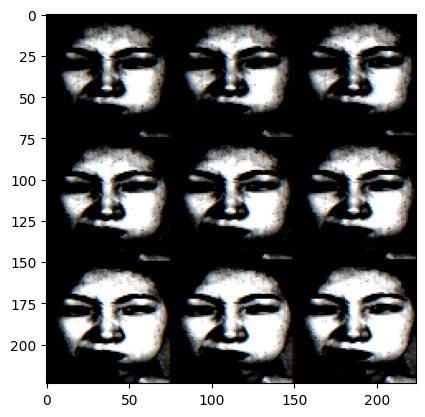

In [2]:
# Dataset Creation
train_dataset = myDataset(directory = "Custom All/DATASET/train", transform = train_transform)
val_dataset = myDataset(directory = "Custom All/DATASET/validation", transform = val_transform)
test_dataset = myDataset(directory = "Custom All/DATASET/test", transform = test_transform)

print(f'Train set length: '+ str(len(train_dataset)))
print(f'Test set length: '+ str(len(val_dataset)))
print(f'Validation set length: '+ str(len(test_dataset)))

# DataLoader Creation
train_loader = DataLoader(train_dataset, batch_size = 16, shuffle = True, num_workers=8)
val_loader = DataLoader(val_dataset, batch_size = 16, shuffle = False, num_workers=8)
test_loader = DataLoader(test_dataset, batch_size = 16, shuffle = False, num_workers=8)

# View shape of data
train_iter = iter(train_dataset)
img, label = next(train_iter)
print(img.shape, label)

np_img = img.numpy()
print(label)
plt.imshow(np_img.reshape((224,224,3)))



In [3]:
import torch
import torch.nn as nn
import torch.optim as optim

class ArchitectureTwo(nn.Module):
    
    def __init__(self):
        super(ArchitectureTwo, self).__init__()

        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1)  
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)  
        
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(2, 2)  

        self.batch_norm1 = nn.BatchNorm2d(32)
        self.batch_norm2 = nn.BatchNorm2d(64)

        self.flatten = nn.Flatten()
        self.fc = nn.Linear(56 * 56 * 64, 7)

        self.dropout1 = nn.Dropout(p=0.3)
        self.dropout2 = nn.Dropout(p=0.3)

    def forward(self, x):
        x = self.conv1(x)
        x = self.batch_norm1(x)
        x = self.relu(x)
        x = self.pool(x)
        x = self.dropout1(x)

        x = self.conv2(x)
        x = self.batch_norm2(x)
        x = self.relu(x)
        x = self.pool(x)
        x = self.dropout2(x)

        
        x = self.flatten(x)
        x = self.fc(x)
        return x


100%|██████████| 203/203 [00:06<00:00, 31.17it/s]


Adam
Epoch 1/50, Training Loss: 1.7585, Validation Loss: 1.5256
Epoch 1/50, Training Acc: 33.884099616858244, Validation Accuracy: 49.75961538461539
SGD
Epoch 1/50, Training Loss: 4.2670, Validation Loss: 3.5363
Epoch 1/50, Training Acc: 37.10317460317461, Validation Accuracy: 46.875


100%|██████████| 203/203 [00:06<00:00, 32.18it/s]


Adam
Epoch 2/50, Training Loss: 1.4582, Validation Loss: 1.3693
Epoch 2/50, Training Acc: 47.60878489326765, Validation Accuracy: 56.25
SGD
Epoch 2/50, Training Loss: 2.6812, Validation Loss: 1.9840
Epoch 2/50, Training Acc: 51.01943076081007, Validation Accuracy: 58.41346153846154


100%|██████████| 203/203 [00:06<00:00, 32.12it/s]


...

Adam
Epoch 48/50, Training Loss: 0.4048, Validation Loss: 0.7257
Epoch 48/50, Training Acc: 86.92186644772852, Validation Accuracy: 74.27884615384616
SGD
Epoch 48/50, Training Loss: 0.1492, Validation Loss: 0.9657
Epoch 48/50, Training Acc: 95.25862068965517, Validation Accuracy: 76.20192307692307


100%|██████████| 203/203 [00:06<00:00, 31.95it/s]


Adam
Epoch 49/50, Training Loss: 0.3989, Validation Loss: 0.7203
Epoch 49/50, Training Acc: 87.69157088122606, Validation Accuracy: 73.79807692307693
SGD
Epoch 49/50, Training Loss: 0.1378, Validation Loss: 0.9566
Epoch 49/50, Training Acc: 95.35782703886152, Validation Accuracy: 76.4423076923077


100%|██████████| 203/203 [00:06<00:00, 32.08it/s]


Adam
Epoch 50/50, Training Loss: 0.3586, Validation Loss: 0.7037
Epoch 50/50, Training Acc: 89.16940339354133, Validation Accuracy: 75.72115384615384
SGD
Epoch 50/50, Training Loss: 0.1359, Validation Loss: 0.9583
Epoch 50/50, Training Acc: 95.63492063492063, Validation Accuracy: 75.96153846153845
Models saved successfully!
Test Adam Loss: 0.7723, Test Adam Accuracy: 72.55%
Test SGD Loss: 1.1492, Test SGD Accuracy: 74.02%


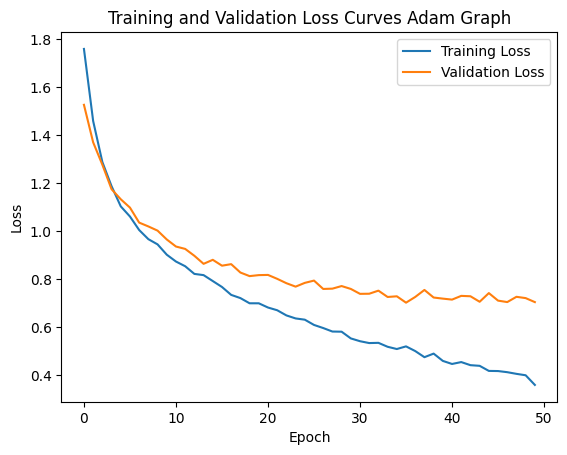

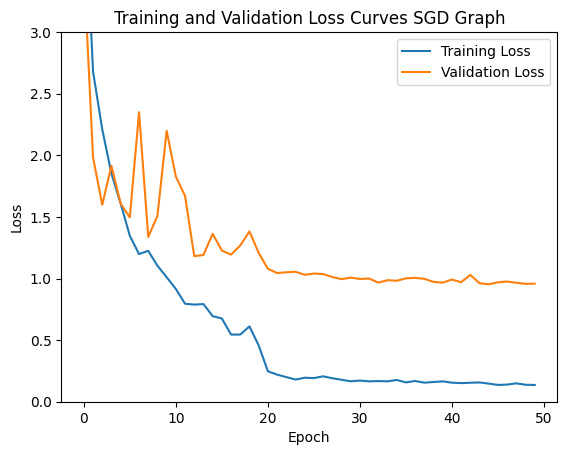

In [ ]:
# Train and Test of Architecture Two using *un-weighted* Cross-Entropy Loss function

# Model Instance
model_one_a = ArchitectureTwo().to(device)
model_one_b = ArchitectureTwo().to(device)

# Epochs
num_epochs = 50

# Optimizer
adamOptimizer = optim.Adam(model_one_a.parameters(), lr=0.000005, weight_decay=0.01)
sdgOptimizer = optim.SGD(model_one_b.parameters(), lr=0.0001, momentum=0.9)

# Loss Function
criterion = nn.CrossEntropyLoss()

# Learning Rate Scheduler
adam_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(adamOptimizer, mode='min', factor=0.1, patience= 12)
sdg_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(sdgOptimizer, mode='min', factor=0.1, patience=6)

(unweighted_train_losses_a, unweighted_val_losses_a, unweighted_train_accuracy_a, unweighted_val_accuracy_a, 
 unweighted_train_losses_b, unweighted_val_losses_b, unweighted_train_accuracy_b, unweighted_val_accuracy_b) = train(model_one_a, model_one_b, device, train_loader, val_loader, 
                                                                                                                        adamOptimizer, sdgOptimizer, adam_scheduler, sdg_scheduler, num_epochs, criterion, 
                                                                                                                        'Custom All/Architecture Two/Unweighted Architecture Two B Adam.pth', 
                                                                                                                        'Custom All/Architecture Two/Unweighted Architecture Two B SGD.pth')

a_y_true, a_y_pred, a_y_score = test(model_one_a, device, criterion, test_loader, split='Test Adam')
b_y_true, b_y_pred, b_y_score = test(model_one_b, device, criterion, test_loader, split='Test SGD')

# Print metrics a
lossPlot(unweighted_train_losses_a, unweighted_val_losses_a, 'Adam Graph')

# Print metrics b
lossPlot(unweighted_train_losses_b, unweighted_val_losses_b, 'SGD Graph')


{'0': 396, '1': 406, '2': 382, '3': 416, '4': 382, '5': 425, '6': 834}
3241
{'0': 1.1691919191919191, '1': 1.1403940886699508, '2': 1.212041884816754, '3': 1.1129807692307692, '4': 1.212041884816754, '5': 1.0894117647058823, '6': 0.5551558752997602}
[1.16919192 1.14039409 1.21204188 1.11298077 1.21204188 1.08941176
 0.55515588]


100%|██████████| 203/203 [00:06<00:00, 32.10it/s]


Adam
Epoch 1/50, Training Loss: 1.8416, Validation Loss: 1.5350
Epoch 1/50, Training Acc: 29.912424740010945, Validation Accuracy: 43.269230769230774
SGD
Epoch 1/50, Training Loss: 4.2088, Validation Loss: 3.5148
Epoch 1/50, Training Acc: 35.201149425287355, Validation Accuracy: 36.05769230769231


100%|██████████| 203/203 [00:06<00:00, 32.11it/s]


Adam
Epoch 2/50, Training Loss: 1.5300, Validation Loss: 1.3974
Epoch 2/50, Training Acc: 44.68390804597701, Validation Accuracy: 54.08653846153846
SGD
Epoch 2/50, Training Loss: 3.0533, Validation Loss: 1.8221
Epoch 2/50, Training Acc: 45.60071154898741, Validation Accuracy: 56.49038461538461


...

Adam
Epoch 48/50, Training Loss: 0.4301, Validation Loss: 0.7026
Epoch 48/50, Training Acc: 86.15216201423098, Validation Accuracy: 76.4423076923077
SGD
Epoch 48/50, Training Loss: 0.2096, Validation Loss: 0.9980
Epoch 48/50, Training Acc: 92.30979748221128, Validation Accuracy: 75.48076923076923


100%|██████████| 203/203 [00:06<00:00, 32.02it/s]


Adam
Epoch 49/50, Training Loss: 0.4158, Validation Loss: 0.7110
Epoch 49/50, Training Acc: 86.21373836891078, Validation Accuracy: 75.0
SGD
Epoch 49/50, Training Loss: 0.2363, Validation Loss: 0.9398
Epoch 49/50, Training Acc: 91.6871921182266, Validation Accuracy: 75.0


100%|██████████| 203/203 [00:06<00:00, 31.92it/s]


Adam
Epoch 50/50, Training Loss: 0.4129, Validation Loss: 0.7110
Epoch 50/50, Training Acc: 87.09975369458128, Validation Accuracy: 74.51923076923077
SGD
Epoch 50/50, Training Loss: 0.2653, Validation Loss: 1.0618
Epoch 50/50, Training Acc: 90.82512315270937, Validation Accuracy: 72.83653846153845
Models saved successfully!
Test Adam Loss: 0.8087, Test Adam Accuracy: 72.30%
Test SGD Loss: 1.1605, Test SGD Accuracy: 74.26%


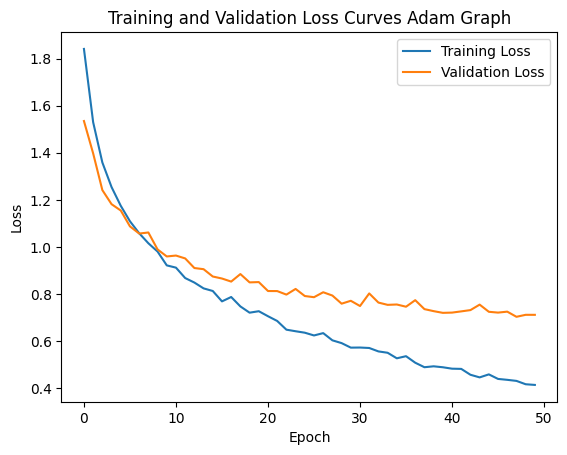

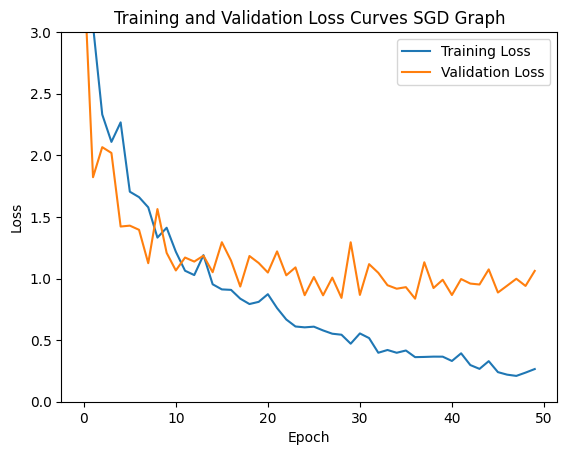

In [ ]:
# Train and Test of ArchitectureOne using *weighted* Cross-Entropy Loss function
# Model Instance
model_one_weighted_a = ArchitectureTwo().to(device)
model_one_weighted_b = ArchitectureTwo().to(device)

# Epochs
num_epochs = 50

# Optimizer
weighted_adamOptimizer = optim.Adam(model_one_weighted_a.parameters(), lr=0.000005, weight_decay=0.1)
weighted_sgdOptimizer = optim.SGD(model_one_weighted_b.parameters(), lr=0.0001, momentum=0.9)

# Loss Function
criterion = nn.CrossEntropyLoss(weight = weighted_loss(device, train_dataset, 7))

# Learning Rate Scheduler
# Learning Rate Scheduler
adam_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(adamOptimizer, mode='min', factor=0.1, patience=7)
sdg_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(sdgOptimizer, mode='min', factor=0.1, patience=10)

(weighted_train_losses_a, weighted_val_losses_a, weighted_train_accuracy_a, weighted_val_accuracy_a, 
 weighted_train_losses_b, weighted_val_losses_b, weighted_train_accuracy_b, weighted_val_accuracy_b) = train(model_one_weighted_a, model_one_weighted_b, device, train_loader, val_loader, 
                                                                                                                    weighted_adamOptimizer, weighted_sgdOptimizer, lr_scheduler_a= adam_scheduler, lr_scheduler_b=sdg_scheduler, 
                                                                                                                    num_epochs=num_epochs, criterion=criterion, 
                                                                                                                    name_a= 'Custom All/Architecture Two/Weighted Architecture Two B Adam.pth', 
                                                                                                                    name_b= 'Custom All/Architecture Two/Weighted Architecture Two B SGD.pth')

a_y_true, a_y_pred, a_y_score = test(model_one_weighted_a, device, criterion, test_loader, split='Test Adam')
b_y_true, b_y_pred, b_y_score = test(model_one_weighted_b, device, criterion, test_loader, split='Test SGD')

# Print metrics a
lossPlot(weighted_train_losses_a, weighted_val_losses_a, 'Adam Graph')

# Print metrics b
lossPlot(weighted_train_losses_b, weighted_val_losses_b, 'SGD Graph')


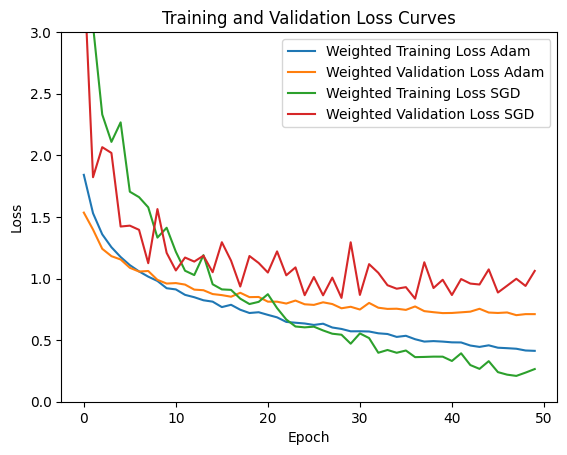

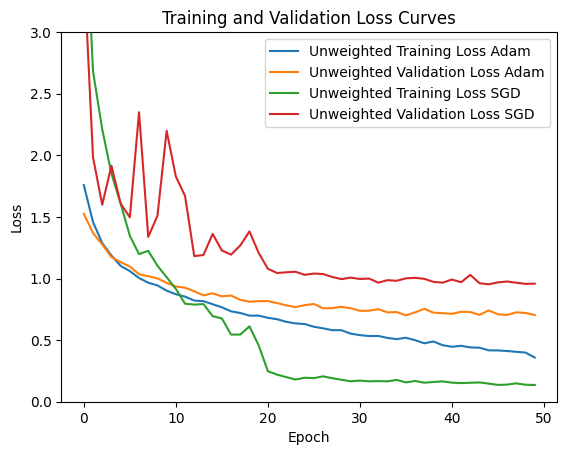

Adam unweighted Split Loss: 0.7723, Adam unweighted Split Accuracy: 72.55%
SGD unweighted Split Loss: 1.1492, SGD unweighted Split Accuracy: 74.02%
{'0': 396, '1': 406, '2': 382, '3': 416, '4': 382, '5': 425, '6': 834}
3241
{'0': 1.1691919191919191, '1': 1.1403940886699508, '2': 1.212041884816754, '3': 1.1129807692307692, '4': 1.212041884816754, '5': 1.0894117647058823, '6': 0.5551558752997602}
[1.16919192 1.14039409 1.21204188 1.11298077 1.21204188 1.08941176
 0.55515588]
Adam weighted Split Loss: 0.8087, Adam weighted Split Accuracy: 72.30%
SGD weighted Split Loss: 1.1605, SGD weighted Split Accuracy: 74.26%
Fin


In [ ]:
def lossPlotUnWeighted():
    # if any(x > 3 for x in unweighted_train_losses_a or unweighted_train_losses_b) or any(x > 3 for x in unweighted_val_losses_a or unweighted_val_losses_b) :
    plt.ylim(0,3)
    plt.plot(unweighted_train_losses_a, label='Unweighted Training Loss Adam')
    plt.plot(unweighted_val_losses_a, label='Unweighted Validation Loss Adam')

    plt.plot(unweighted_train_losses_b, label='Unweighted Training Loss SGD')
    plt.plot(unweighted_val_losses_b, label='Unweighted Validation Loss SGD')

    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss Curves')
    plt.legend()
    plt.show()

def lossPlotWeighted():
    # if any(x > 3 for x in weighted_train_losses_a) or any(x > 3 for x in weighted_val_losses_a) :
    plt.ylim(0,3)
    plt.plot(weighted_train_losses_a, label='Weighted Training Loss Adam')
    plt.plot(weighted_val_losses_a, label='Weighted Validation Loss Adam')

    plt.plot(weighted_train_losses_b, label='Weighted Training Loss SGD')
    plt.plot(weighted_val_losses_b, label='Weighted Validation Loss SGD')

    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss Curves')
    plt.legend()
    plt.show()

lossPlotWeighted()
lossPlotUnWeighted()

criterion = nn.CrossEntropyLoss()
test(model_one_a, device, criterion, test_loader, 'Adam unweighted Split')
test(model_one_b, device, criterion, test_loader, 'SGD unweighted Split')

criterion = nn.CrossEntropyLoss(weight = weighted_loss(device, train_dataset, 7))
test(model_one_weighted_a, device, criterion, test_loader, 'Adam weighted Split')
test(model_one_weighted_b, device, criterion, test_loader, 'SGD weighted Split')

print('Fin')

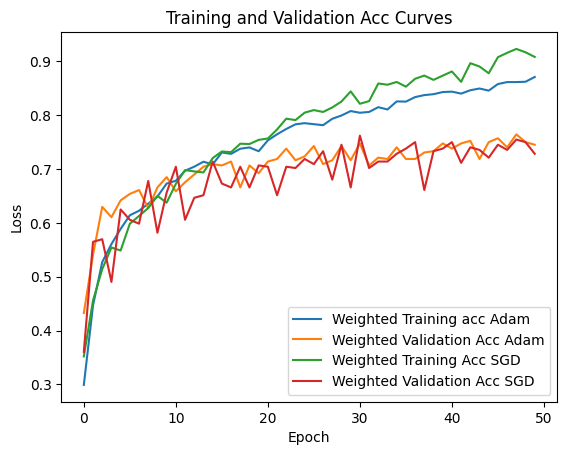

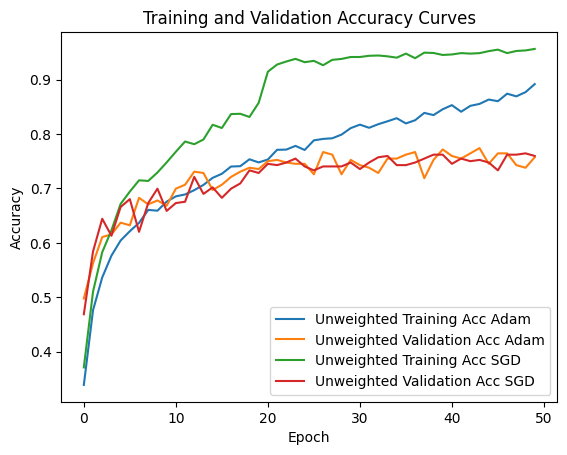

In [ ]:
def lossPlotUnWeighted():
    # if any(x > 3 for x in unweighted_train_losses_a or unweighted_train_losses_b) or any(x > 3 for x in unweighted_val_losses_a or unweighted_val_losses_b) :
    plt.plot(unweighted_train_accuracy_a, label='Unweighted Training Acc Adam')
    plt.plot(unweighted_val_accuracy_a, label='Unweighted Validation Acc Adam')

    plt.plot(unweighted_train_accuracy_b, label='Unweighted Training Acc SGD')
    plt.plot(unweighted_val_accuracy_b, label='Unweighted Validation Acc SGD')

    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Training and Validation Accuracy Curves')
    plt.legend()
    plt.show()

def lossPlotWeighted():
    # if any(x > 3 for x in weighted_train_losses_a) or any(x > 3 for x in weighted_val_losses_a) :

    plt.plot(weighted_train_accuracy_a, label='Weighted Training acc Adam')
    plt.plot(weighted_val_accuracy_a, label='Weighted Validation Acc Adam')

    plt.plot(weighted_train_accuracy_b, label='Weighted Training Acc SGD')
    plt.plot(weighted_val_accuracy_b, label='Weighted Validation Acc SGD')

    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Acc Curves')
    plt.legend()
    plt.show()

lossPlotWeighted()
lossPlotUnWeighted()

/user/HS401/ob00564/Documents/COM3001


/tmp/ipykernel_3249473/1178686747.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  myModel.load_state_dict(torch.load('Custom All/Architecture Two/Unweighted Architecture

Unweighted Adam Test Loss: 0.8370, Unweighted Adam Test Accuracy: 71.32%
              precision    recall  f1-score   support

       Anger     0.5424    0.6400    0.5872        50
     Disgust     0.7727    0.6667    0.7158        51
        Fear     0.5484    0.3542    0.4304        48
   Happiness     0.9600    0.9231    0.9412        52
     Sadness     0.5000    0.6667    0.5714        48
    Surprise     0.6970    0.8519    0.7667        54
     Neurtal     0.8723    0.7810    0.8241       105

    accuracy                         0.7132       408
   macro avg     0.6990    0.6976    0.6910       408
weighted avg     0.7255    0.7132    0.7128       408



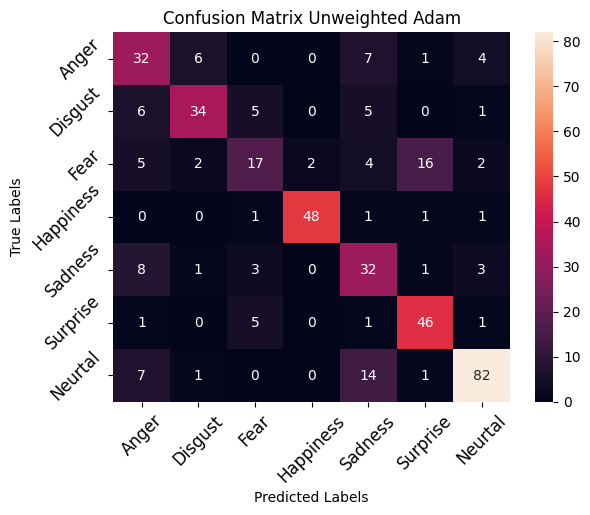

In [4]:

myModel = ArchitectureTwo()
print(os.getcwd())
myModel.load_state_dict(torch.load('Custom All/Architecture Two/Unweighted Architecture Two Adam.pth'))
myModel.to('cuda')
myModel.eval()
criterion = nn.CrossEntropyLoss()
a_unweighted_y_true, a_unweighted_y_pred, _ = test(myModel=myModel,device='cuda', criterion = criterion, data_loader= test_loader, split='Unweighted Adam Test')
confusionMatrixPlot(y_true=a_unweighted_y_true, y_pred=a_unweighted_y_pred, title= 'Unweighted Adam')

/user/HS401/ob00564/Documents/COM3001


/tmp/ipykernel_3249473/2675433658.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  myModel.load_state_dict(torch.load('Custom All/Architecture Two/Unweighted Architecture

Unweighted SGD Test Loss: 0.8587, Unweighted SGD Test Accuracy: 70.34%
              precision    recall  f1-score   support

       Anger     0.6562    0.4200    0.5122        50
     Disgust     0.7727    0.6667    0.7158        51
        Fear     0.5000    0.5417    0.5200        48
   Happiness     0.8654    0.8654    0.8654        52
     Sadness     0.5333    0.5000    0.5161        48
    Surprise     0.7818    0.7963    0.7890        54
     Neurtal     0.7344    0.8952    0.8069       105

    accuracy                         0.7034       408
   macro avg     0.6920    0.6693    0.6751       408
weighted avg     0.7013    0.7034    0.6965       408



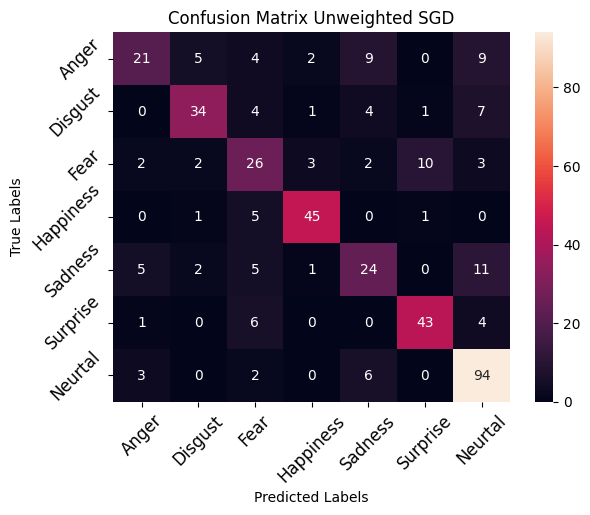

In [5]:
myModel = ArchitectureTwo()
print(os.getcwd())
myModel.load_state_dict(torch.load('Custom All/Architecture Two/Unweighted Architecture Two SGD.pth'))
myModel.to('cuda')
myModel.eval()
criterion = nn.CrossEntropyLoss()
b_unweighted_y_true, b_unweighted_y_pred, _ = test(myModel=myModel,device='cuda', criterion = criterion, data_loader= test_loader, split='Unweighted SGD Test')
confusionMatrixPlot(y_true=b_unweighted_y_true, y_pred=b_unweighted_y_pred, title= 'Unweighted SGD')

/user/HS401/ob00564/Documents/COM3001
{'0': 396, '1': 406, '2': 382, '3': 416, '4': 382, '5': 425, '6': 834}
3241
{'0': 1.1691919191919191, '1': 1.1403940886699508, '2': 1.212041884816754, '3': 1.1129807692307692, '4': 1.212041884816754, '5': 1.0894117647058823, '6': 0.5551558752997602}
[1.16919192 1.14039409 1.21204188 1.11298077 1.21204188 1.08941176
 0.55515588]


/tmp/ipykernel_3249473/2306468560.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  myModel.load_state_dict(torch.load('Custom All/Architecture Two/Weighted Architecture T

Weighted Adam Test Loss: 0.8309, Weighted Adam Test Accuracy: 71.57%
              precision    recall  f1-score   support

       Anger     0.6667    0.6400    0.6531        50
     Disgust     0.7959    0.7647    0.7800        51
        Fear     0.3710    0.4792    0.4182        48
   Happiness     0.9400    0.9038    0.9216        52
     Sadness     0.8065    0.5208    0.6329        48
    Surprise     0.7447    0.6481    0.6931        54
     Neurtal     0.7521    0.8667    0.8053       105

    accuracy                         0.7157       408
   macro avg     0.7253    0.6891    0.7006       408
weighted avg     0.7316    0.7157    0.7176       408



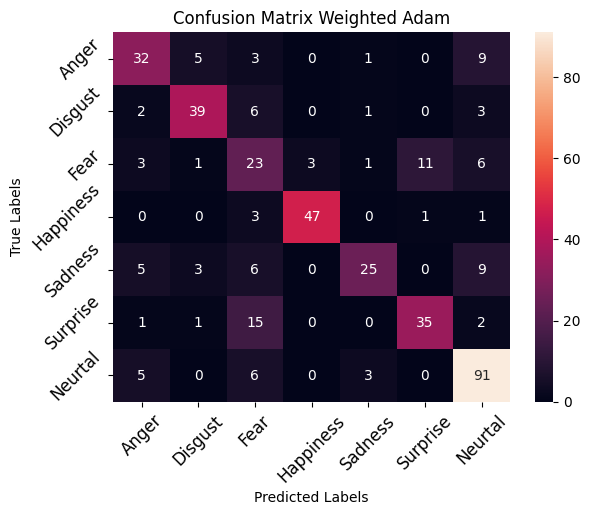

In [6]:
myModel = ArchitectureTwo()
print(os.getcwd())
myModel.load_state_dict(torch.load('Custom All/Architecture Two/Weighted Architecture Two Adam.pth'))
myModel.to('cuda')
myModel.eval()
criterion = nn.CrossEntropyLoss(weight = weighted_loss(device, train_dataset, 7))
a_weighted_y_true, a_weighted_y_pred, _ = test(myModel=myModel,device='cuda', criterion = criterion, data_loader= test_loader, split='Weighted Adam Test')
confusionMatrixPlot(a_weighted_y_true, a_weighted_y_pred, title= 'Weighted Adam')

/user/HS401/ob00564/Documents/COM3001
{'0': 396, '1': 406, '2': 382, '3': 416, '4': 382, '5': 425, '6': 834}
3241
{'0': 1.1691919191919191, '1': 1.1403940886699508, '2': 1.212041884816754, '3': 1.1129807692307692, '4': 1.212041884816754, '5': 1.0894117647058823, '6': 0.5551558752997602}
[1.16919192 1.14039409 1.21204188 1.11298077 1.21204188 1.08941176
 0.55515588]


/tmp/ipykernel_3249473/1512859621.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  myModel.load_state_dict(torch.load('Custom All/Architecture Two/Weighted Architecture T

Weighted SGD Test Loss: 0.9221, Weighted SGD Test Accuracy: 71.57%
              precision    recall  f1-score   support

       Anger     0.7297    0.5400    0.6207        50
     Disgust     0.7255    0.7255    0.7255        51
        Fear     0.4182    0.4792    0.4466        48
   Happiness     0.8727    0.9231    0.8972        52
     Sadness     0.5814    0.5208    0.5495        48
    Surprise     0.7800    0.7222    0.7500        54
     Neurtal     0.7949    0.8857    0.8378       105

    accuracy                         0.7157       408
   macro avg     0.7003    0.6852    0.6896       408
weighted avg     0.7167    0.7157    0.7132       408



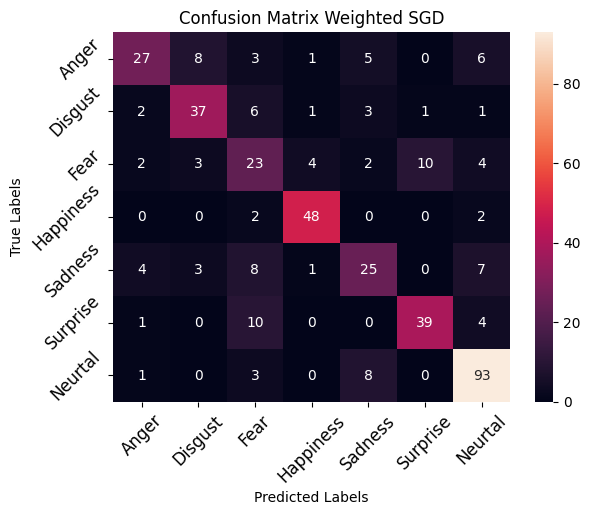

In [7]:
myModel = ArchitectureTwo()
print(os.getcwd())
myModel.load_state_dict(torch.load('Custom All/Architecture Two/Weighted Architecture Two SGD.pth'))
myModel.to('cuda')
myModel.eval()
criterion = nn.CrossEntropyLoss(weight = weighted_loss(device, train_dataset, 7))
b_weighted_y_true, b_weighted_y_pred, _ = test(myModel=myModel,device='cuda', criterion = criterion, data_loader= test_loader, split='Weighted SGD Test')
confusionMatrixPlot(b_weighted_y_true, b_weighted_y_pred, title= 'Weighted SGD')

**Analysis & Improvements**:

Changes made:
* Increased Learning Rate to 0.001
* Implemented lr_schedulers - ReduceLROnPlateau
* Add additional convolutional layer
* Implemented Regularization Techniques: increased weight decay, added dropout layers

Using figures above (unweighted):
* Adam:
    * Training is more stable & less overfitting (9th epoch), training and validation loss decreases at a steady-ish rate
    * Learning Rate Scheduler needs further tuning
* SGD:
    * Training is far more stable & minimal overfitting, losses are close to one-another, and move together

Using figures above (weighted):
* Adam:
    * Training is more stable & less overfitting, however overfitting after 6th epoch
    * Learning Rate Scheduler needs further tuning
* SGD:
    * Training is far more stable & minimal overfitting, however begins to overfit after 15th epoch


Overall, the training loss and validating loss are beginning to decrease at a similar rate, however issues still occuring:
* Overfitting: the loss curves are divering from one another, and training curve is always decreasing (model is memorizing the data)
* Simple Model: the model is too simple, its unable to capture underlying features 



